In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
def imshow(image= None):
  """
  Display a BGR image using Matplotlib.

  Converts the input image from OpenCV's BGR color space to RGB
  before displaying it and hides the axis for cleaner visualization.
  """
  plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
  plt.axis("off")
  plt.show()

# **preprocessing**

In [4]:
def oreder_points(points):
  points = points.reshape((4,2)).astype(np.float32)
  new_points = np.zeros((4,2)).astype(np.float32)
  sum = points.sum(axis=1)
  new_points[0] = points[np.argmin(sum)]
  new_points[2] = points[np.argmax(sum)]
  diff = np.diff(points, axis=1)
  new_points[1] = points[np.argmin(diff)]
  new_points[3] = points[np.argmax(diff)]

  return new_points

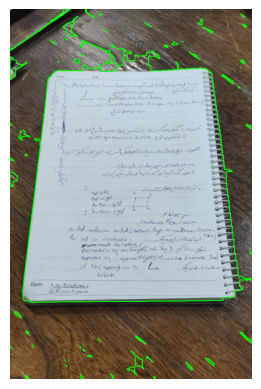

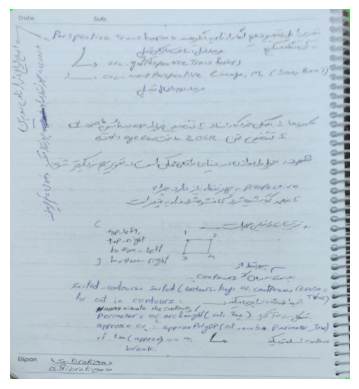

In [41]:
image = cv.imread("/content/drive/MyDrive/Colab Notebooks/Image/doc.jpg")
# convert to gray scale
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
# blur
blur = cv.medianBlur(gray, 5)
# edge
kernel = np.ones((7,7), np.uint8)
edges = cv.Canny(blur, 140, 200)
edges = cv.dilate(edges, kernel, iterations=3)
edges = cv.erode(edges, kernel, iterations=3)
# find contoures
contour, hirachy = cv.findContours(edges, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
cv.drawContours(image, contour, -1, (0,255,0), 2)
imshow(image)
# sort contours
sorted_contour = sorted(contour, key=cv.contourArea, reverse=True)

# find 4-point in image
target_points = []
for c in sorted_contour:
  approx = cv.approxPolyDP(c, 0.03 * cv.arcLength(c, True), True)
  if len(approx) == 4:
    target_points = approx
    break
if target_points is None:
  print("target points in none")
  target_points = contour[0]
# order target points
target_points = target_points.reshape((4,2)).astype(np.float32)
target_points = oreder_points(target_points)


(tl, tr, br, bl) = target_points
# Compute output width
widthA = np.linalg.norm(br - bl)
widthB = np.linalg.norm(tr - tl)

maxWidth = int(max(widthA, widthB))

# Compute output height
heightA = np.linalg.norm(tr - br)
heightB = np.linalg.norm(tl - bl)

maxHeight = int(max(heightA, heightB))

# Destination points
dst_pts = np.array([
    [0, 0],
    [maxWidth - 1, 0],
    [maxWidth - 1, maxHeight - 1],
    [0, maxHeight - 1]
], dtype=np.float32)

#prespectiveTransform
M = cv.getPerspectiveTransform(target_points, dst_pts)
dst = cv.warpPerspective(image, M, (maxWidth, maxHeight))
imshow(dst)
